In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# Dataset Features Description

The original dataset documentation was not available. Therefore, the following feature descriptions are inferred from common terminology used in financial markets, cryptocurrency trading, and technical analysis.

## Price Data

| Feature | Description |
|---------|-------------|
| `price_open` | Opening Bitcoin price during the 15-minute interval. |
| `price_high` | Highest Bitcoin price during the interval. |
| `price_low` | Lowest Bitcoin price during the interval. |
| `price_close` | Closing Bitcoin price during the interval. |

## Trading Volume

| Feature | Description |
|---------|-------------|
| `volume_btc` | Bitcoin trading volume during the interval, likely measured in BTC. |

## Bollinger Bands

| Feature | Description |
|---------|-------------|
| `bb_upper_abs` | Upper Bollinger Band value. |
| `bb_middle_abs` | Middle Bollinger Band (moving average). |
| `bb_lower_abs` | Lower Bollinger Band value. |

## MACD Indicators

| Feature | Description |
|---------|-------------|
| `macd_line_abs` | MACD (Moving Average Convergence Divergence) line. |
| `macd_signal_abs` | MACD signal line. |
| `macd_hist_abs` | MACD histogram, calculated as the difference between the MACD line and the signal line. |

## Trend and Momentum Indicators

| Feature | Description |
|---------|-------------|
| `rsi_14` | Relative Strength Index calculated over 14 periods. Values above 70 generally indicate overbought conditions, while values below 30 indicate oversold conditions. |
| `adx_14` | Average Directional Index over 14 periods, measuring the strength of a trend regardless of its direction. |
| `adx_pos_14` | Positive Directional Indicator (+DI), representing bullish directional movement. |
| `adx_neg_14` | Negative Directional Indicator (-DI), representing bearish directional movement. |
| `atr_14` | Average True Range over 14 periods, measuring market volatility. |

## ETF Flows

| Feature | Description |
|---------|-------------|
| `etf_flow_24h` | Estimated net Bitcoin ETF inflows or outflows over the previous 24 hours. Positive values indicate net inflows, while negative values indicate net outflows. |

## Open Interest (Futures Market)

| Feature | Description |
|---------|-------------|
| `open_oi` | Opening Open Interest value during the interval. |
| `high_oi` | Highest Open Interest value during the interval. |
| `low_oi` | Lowest Open Interest value during the interval. |
| `close_oi` | Closing Open Interest value during the interval. Open Interest represents the total number of outstanding futures contracts. |

## Funding Rate (Perpetual Futures)

| Feature | Description |
|---------|-------------|
| `open_fr` | Opening funding rate during the interval. |
| `high_fr` | Highest funding rate during the interval. |
| `low_fr` | Lowest funding rate during the interval. |
| `close_fr` | Closing funding rate during the interval. Positive funding rates indicate long traders pay short traders, whereas negative funding rates indicate the opposite. |

## Derivatives Market Metrics

| Feature | Description |
|---------|-------------|
| `btc_shortvslong_abs` | Ratio between short and long Bitcoin positions (or vice versa, depending on the data provider). The exact definition cannot be confirmed without the original documentation. |
| `liquidations_long_abs` | Total value of liquidated long positions during the interval. |
| `liquidations_short_abs` | Total value of liquidated short positions during the interval. |

## Market Sentiment

| Feature | Description |
|---------|-------------|
| `fear_greed_abs` | Cryptocurrency Fear & Greed Index, representing overall market sentiment. The index typically ranges from 0 (Extreme Fear) to 100 (Extreme Greed). |

## Other Financial Assets

| Feature | Description |
|---------|-------------|
| `ethusdt_abs` | Price of the ETH/USDT trading pair. |
| `solusdt_abs` | Price of the SOL/USDT trading pair. |
| `xrpusdt_abs` | Price of the XRP/USDT trading pair. |
| `nasdaq_abs` | Value of the NASDAQ stock market index. |
| `tsy10y_abs` | Yield of the U.S. 10-Year Treasury bond. |

## Percentage Change Features

The following variables represent the percentage change of the corresponding feature relative to the previous 15-minute interval.

| Feature | Description |
|---------|-------------|
| `price_open_pct_change` | Percentage change of `price_open`. |
| `price_high_pct_change` | Percentage change of `price_high`. |
| `price_low_pct_change` | Percentage change of `price_low`. |
| `price_close_pct_change` | Percentage change of `price_close`. |
| `volume_btc_pct_change` | Percentage change of `volume_btc`. |
| `bb_upper_abs_pct_change` | Percentage change of `bb_upper_abs`. |
| `bb_middle_abs_pct_change` | Percentage change of `bb_middle_abs`. |
| `bb_lower_abs_pct_change` | Percentage change of `bb_lower_abs`. |
| `macd_line_abs_pct_change` | Percentage change of `macd_line_abs`. |
| `macd_signal_abs_pct_change` | Percentage change of `macd_signal_abs`. |
| `macd_hist_abs_pct_change` | Percentage change of `macd_hist_abs`. |
| `rsi_14_pct_change` | Percentage change of `rsi_14`. |
| `adx_14_pct_change` | Percentage change of `adx_14`. |
| `adx_pos_14_pct_change` | Percentage change of `adx_pos_14`. |
| `adx_neg_14_pct_change` | Percentage change of `adx_neg_14`. |
| `atr_14_pct_change` | Percentage change of `atr_14`. |
| `etf_flow_24h_pct_change` | Percentage change of `etf_flow_24h`. |
| `btc_shortvslong_abs_pct_change` | Percentage change of `btc_shortvslong_abs`. |
| `fear_greed_abs_pct_change` | Percentage change of `fear_greed_abs`. |

# Data downloading 

In [3]:
df_crypto_bybit_original = pd.read_csv('crypto_dataset_bybit_15min.csv', sep=';', decimal='.')
df_crypto_bybit_original.head() 

,Unnamed: 0,price_open,price_high,price_low,price_close,volume_btc,bb_upper_abs,bb_middle_abs,bb_lower_abs,macd_line_abs,...,macd_signal_abs_pct_change,macd_hist_abs_pct_change,rsi_14_pct_change,adx_14_pct_change,adx_pos_14_pct_change,adx_neg_14_pct_change,atr_14_pct_change,etf_flow_24h_pct_change,btc_shortvslong_abs_pct_change,fear_greed_abs_pct_change
0,31.12.2023 21:00,42600.0,42658.2,42590.0,42631.1,4.207941e+07,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31.12.2023 21:15,42631.2,42718.3,42631.1,42678.0,1.482247e+07,NaN,NaN,NaN,3.741311,...,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31.12.2023 21:30,42678.1,42695.9,42592.4,42641.5,2.135532e+07,NaN,NaN,NaN,3.718220,...,79.382817,-20.617183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.12.2023 21:45,42640.0,42640.0,42561.0,42561.1,1.134497e+07,NaN,NaN,NaN,-2.755919,...,-61.064061,-237.987586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31.12.2023 22:00,42561.0,42622.3,42517.7,42559.5,2.898817e+07,NaN,NaN,NaN,-7.924479,...,-323.260249,106.118642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_crypto_bybit_original.rename(columns={df_crypto_bybit_original.columns[0]: "datetime"}, inplace=True)
df_crypto_bybit_original['datetime'] = pd.to_datetime(df_crypto_bybit_original['datetime'], format='%d.%m.%Y %H:%M')
df_crypto_bybit_original.head() 

,datetime,price_open,price_high,price_low,price_close,volume_btc,bb_upper_abs,bb_middle_abs,bb_lower_abs,macd_line_abs,...,macd_signal_abs_pct_change,macd_hist_abs_pct_change,rsi_14_pct_change,adx_14_pct_change,adx_pos_14_pct_change,adx_neg_14_pct_change,atr_14_pct_change,etf_flow_24h_pct_change,btc_shortvslong_abs_pct_change,fear_greed_abs_pct_change
0,2023-12-31 21:00:00,42600.0,42658.2,42590.0,42631.1,4.207941e+07,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-12-31 21:15:00,42631.2,42718.3,42631.1,42678.0,1.482247e+07,NaN,NaN,NaN,3.741311,...,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-12-31 21:30:00,42678.1,42695.9,42592.4,42641.5,2.135532e+07,NaN,NaN,NaN,3.718220,...,79.382817,-20.617183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-12-31 21:45:00,42640.0,42640.0,42561.0,42561.1,1.134497e+07,NaN,NaN,NaN,-2.755919,...,-61.064061,-237.987586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-12-31 22:00:00,42561.0,42622.3,42517.7,42559.5,2.898817e+07,NaN,NaN,NaN,-7.924479,...,-323.260249,106.118642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = df_crypto_bybit_original.copy()
df.set_index("datetime", inplace=True)
df.head()

,price_open,price_high,price_low,price_close,volume_btc,bb_upper_abs,bb_middle_abs,bb_lower_abs,macd_line_abs,macd_signal_abs,...,macd_signal_abs_pct_change,macd_hist_abs_pct_change,rsi_14_pct_change,adx_14_pct_change,adx_pos_14_pct_change,adx_neg_14_pct_change,atr_14_pct_change,etf_flow_24h_pct_change,btc_shortvslong_abs_pct_change,fear_greed_abs_pct_change
datetime,,,,,,,,,,,,,,,,,,,,,
2023-12-31 21:00:00,42600.0,42658.2,42590.0,42631.1,4.207941e+07,NaN,NaN,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:15:00,42631.2,42718.3,42631.1,42678.0,1.482247e+07,NaN,NaN,NaN,3.741311,0.748262,...,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:30:00,42678.1,42695.9,42592.4,42641.5,2.135532e+07,NaN,NaN,NaN,3.718220,1.342254,...,79.382817,-20.617183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:45:00,42640.0,42640.0,42561.0,42561.1,1.134497e+07,NaN,NaN,NaN,-2.755919,0.522619,...,-61.064061,-237.987586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 22:00:00,42561.0,42622.3,42517.7,42559.5,2.898817e+07,NaN,NaN,NaN,-7.924479,-1.166801,...,-323.260249,106.118642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# NaNs analysis 

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 58700 entries, 2023-12-31 21:00:00 to 2025-09-03 07:45:00
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price_open                      58700 non-null  float64
 1   price_high                      58700 non-null  float64
 2   price_low                       58700 non-null  float64
 3   price_close                     58700 non-null  float64
 4   volume_btc                      58700 non-null  float64
 5   bb_upper_abs                    58681 non-null  float64
 6   bb_middle_abs                   58681 non-null  float64
 7   bb_lower_abs                    58681 non-null  float64
 8   macd_line_abs                   58700 non-null  float64
 9   macd_signal_abs                 58700 non-null  float64
 10  macd_hist_abs                   58700 non-null  float64
 11  rsi_14                          58687 non-null  float64
 1

In [7]:
print(f'# Duplicated timestamps: {df.index.duplicated().sum()}')
print(f'# Duplicate rows: {df.duplicated().sum()}') 

# Duplicated timestamps: 0
# Duplicate rows: 0


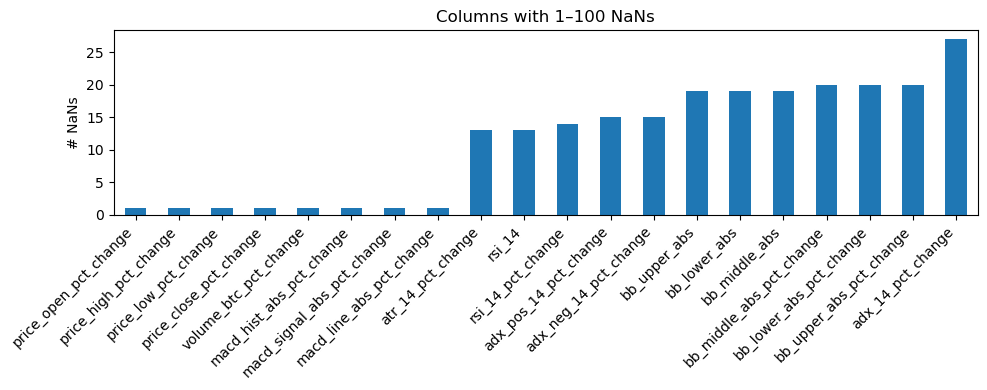

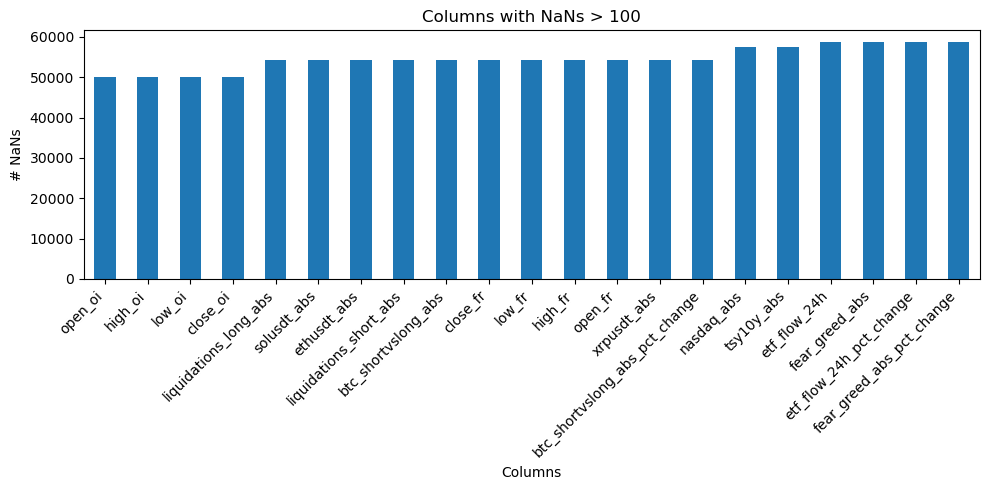

In [8]:
nans_info = df.isna().sum()
few_nans = nans_info[(nans_info > 0) & (nans_info <= 100)]
many_nans = nans_info[nans_info > 100]
    
plt.figure(figsize=(10,4))
few_nans.sort_values().plot(kind="bar")
plt.title("Columns with 1–100 NaNs")
plt.ylabel("# NaNs")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
    
plt.figure(figsize=(10, 5))
many_nans.sort_values().plot(kind='bar')
plt.title("Columns with NaNs > 100")
plt.xlabel("Columns")
plt.ylabel("# NaNs")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


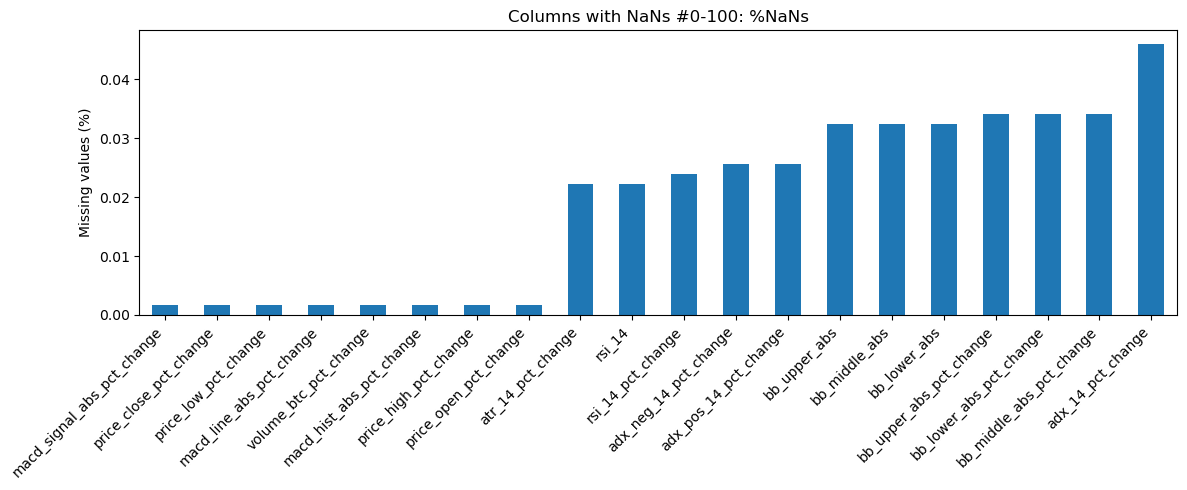

In [10]:
missing_pct = (df.isna().mean() * 100).sort_values()
few_missing = missing_pct[(missing_pct > 0) & (missing_pct <= 100*100/len(df))]
many_missing = missing_pct[missing_pct > 100*100/len(df)]

plt.figure(figsize=(12,5))
few_missing.sort_values().plot(kind='bar')
plt.ylabel("Missing values (%)")
plt.title(f"Columns with NaNs #0-100: %NaNs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 

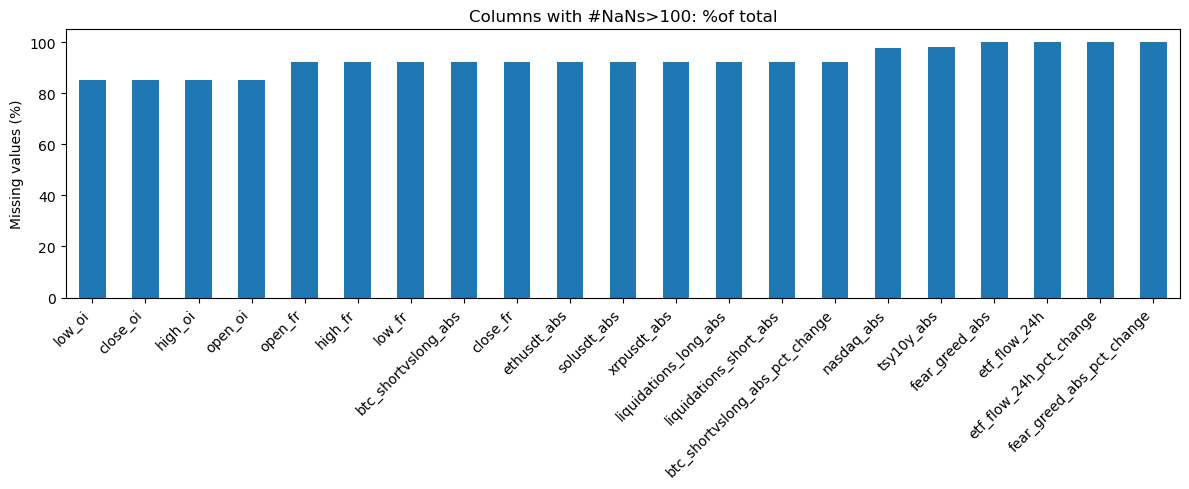

In [11]:
plt.figure(figsize=(12,5))
many_missing.sort_values().plot(kind='bar')
plt.ylabel("Missing values (%)")
plt.title(f"Columns with #NaNs>100: %of total")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 

In [12]:
def inspect_frequency(df, column):
    idx = df[df[column].notna()].index
    print('='*80)
    print(column)
    print('Observations:', len(idx))
    if len(idx) > 1:
        print(idx.to_series().diff().value_counts().head())
    print('First valid index:', df[column].first_valid_index(),'\nLast valid index:', df[column].last_valid_index())
        
    
print('\n=========== MANY MISSING ===========')
for col, value in many_missing.items(): inspect_frequency(df, col)


=========== MANY MISSING ===========
low_oi
Observations: 8640
datetime
0 days 00:15:00    8639
Name: count, dtype: int64
First valid index: 2025-06-05 08:00:00 
Last valid index: 2025-09-03 07:45:00
close_oi
Observations: 8640
datetime
0 days 00:15:00    8639
Name: count, dtype: int64
First valid index: 2025-06-05 08:00:00 
Last valid index: 2025-09-03 07:45:00
high_oi
Observations: 8640
datetime
0 days 00:15:00    8639
Name: count, dtype: int64
First valid index: 2025-06-05 08:00:00 
Last valid index: 2025-09-03 07:45:00
open_oi
Observations: 8640
datetime
0 days 00:15:00    8639
Name: count, dtype: int64
First valid index: 2025-06-05 08:00:00 
Last valid index: 2025-09-03 07:45:00
liquidations_long_abs
Observations: 4500
datetime
0 days 00:15:00    4499
Name: count, dtype: int64
First valid index: 2025-07-18 11:00:00 
Last valid index: 2025-09-03 07:45:00
xrpusdt_abs
Observations: 4500
datetime
0 days 00:15:00    4499
Name: count, dtype: int64
First valid index: 2025-07-18 11:00:00

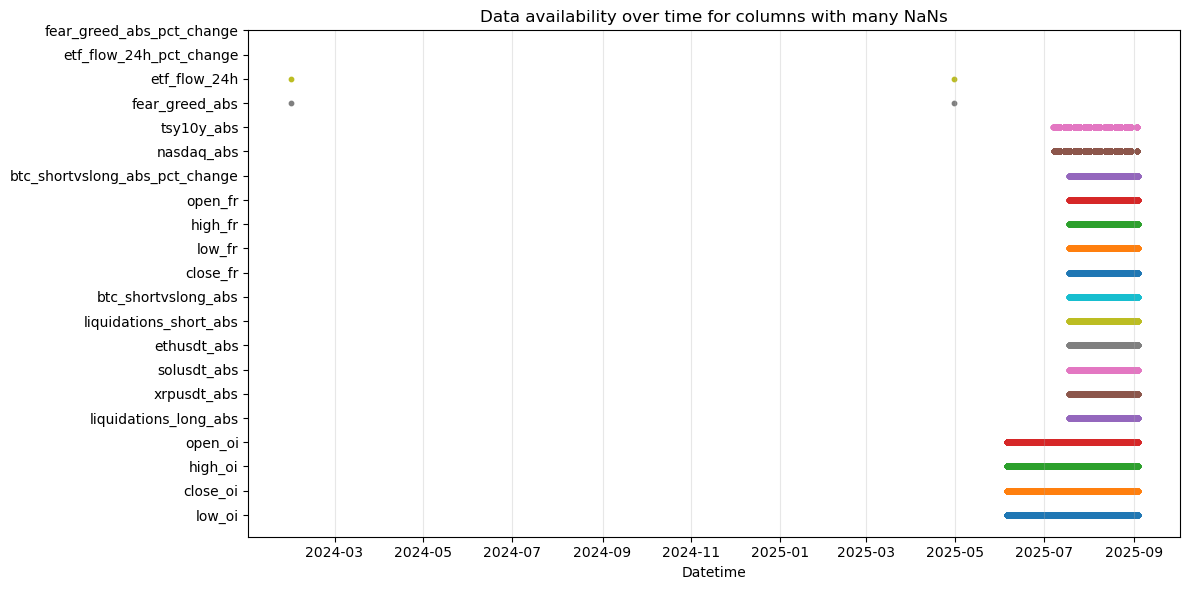

In [13]:
many_missing_cols_names = [col_name for col_name, value in many_missing.items()]

plt.figure(figsize=(12, 6))

for i, col in enumerate(many_missing_cols_names):
    valid = df[df[col].notna()]
    plt.scatter(valid.index, [i] * len(valid), s=10)

plt.yticks(range(len(many_missing_cols_names)), many_missing_cols_names)
plt.xlabel("Datetime")
plt.title("Data availability over time for columns with many NaNs")
plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Following that the data for these features is available only for the short period of time at the end (or even almost fully unavailable), these features are removed from the dataset. 

In [14]:
df_clean1 = df.drop(columns=many_missing_cols_names)

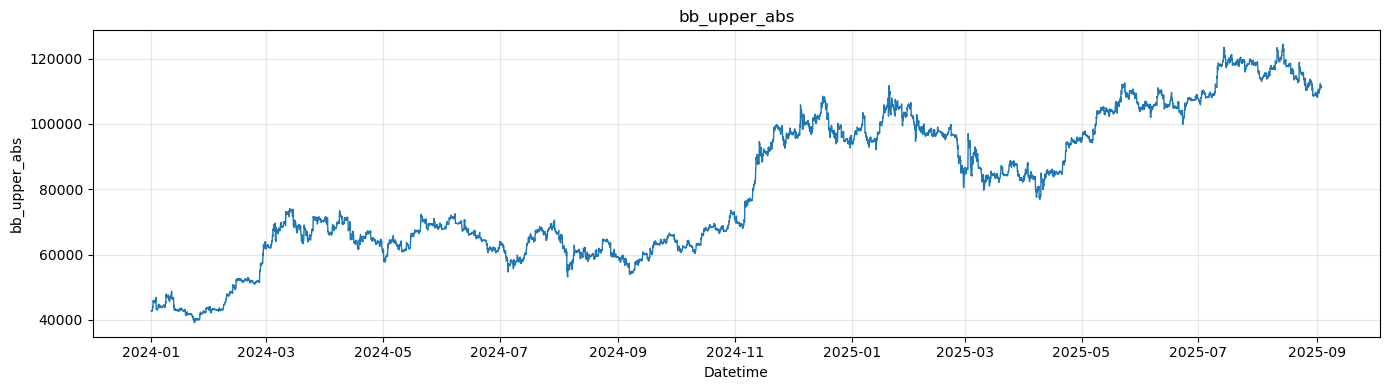

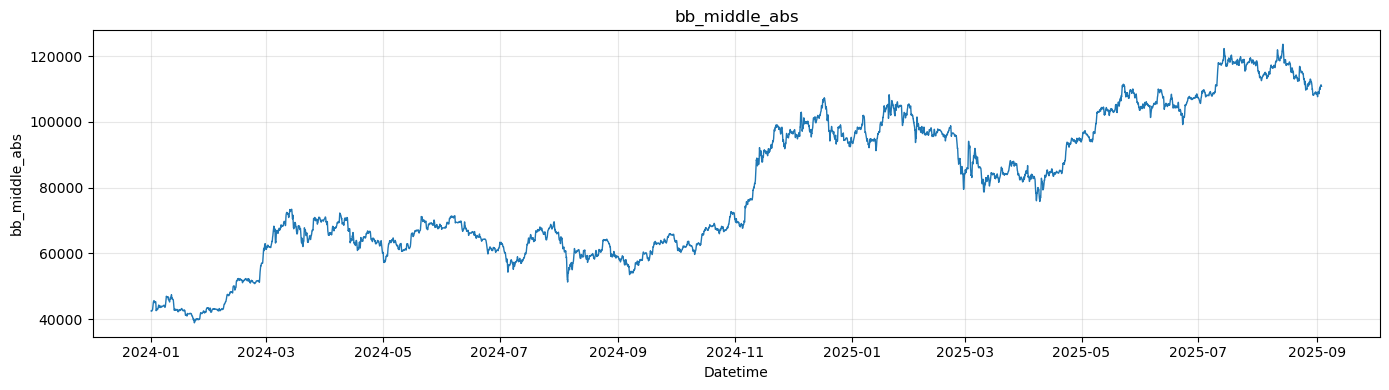

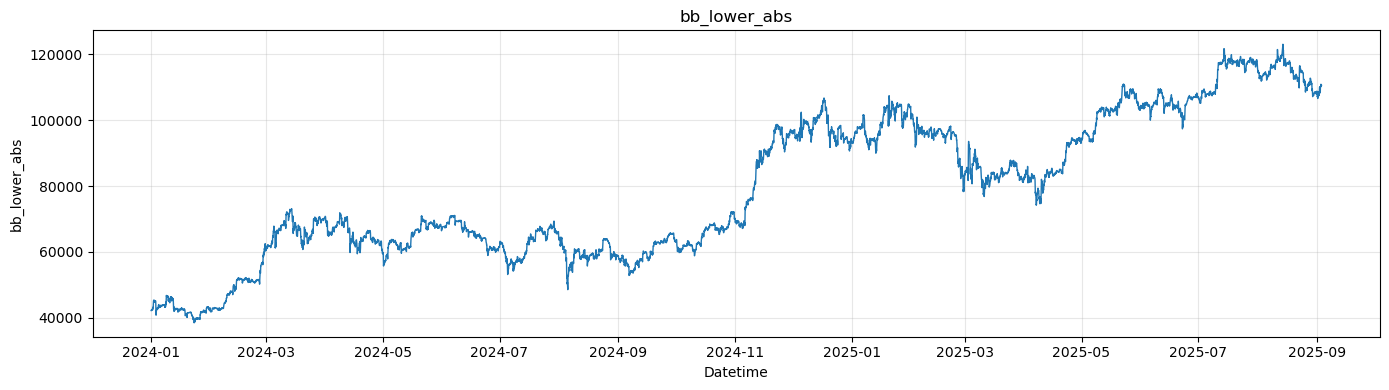

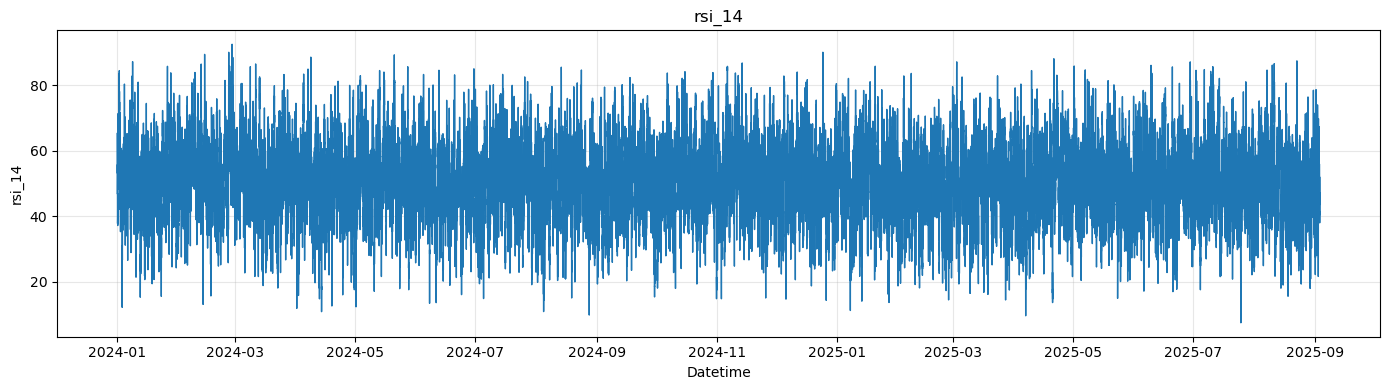

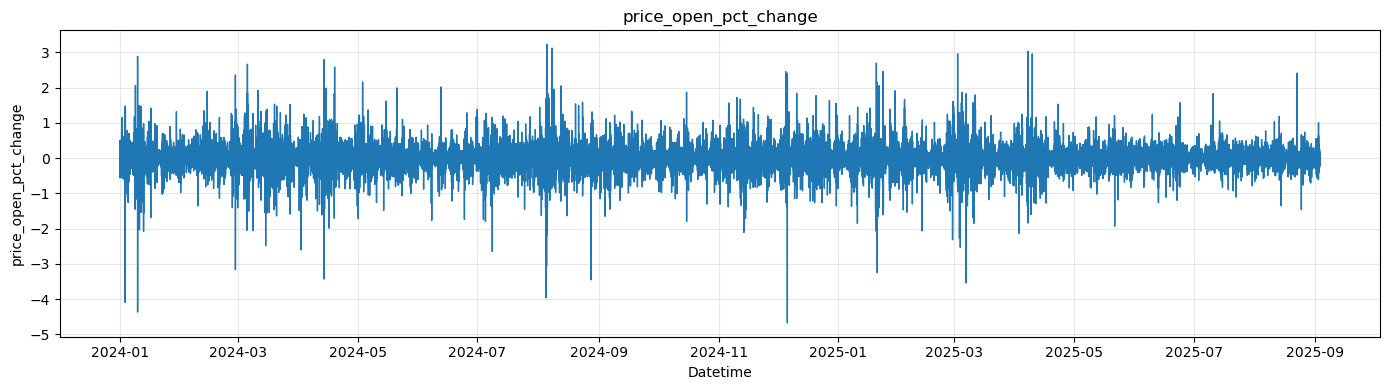

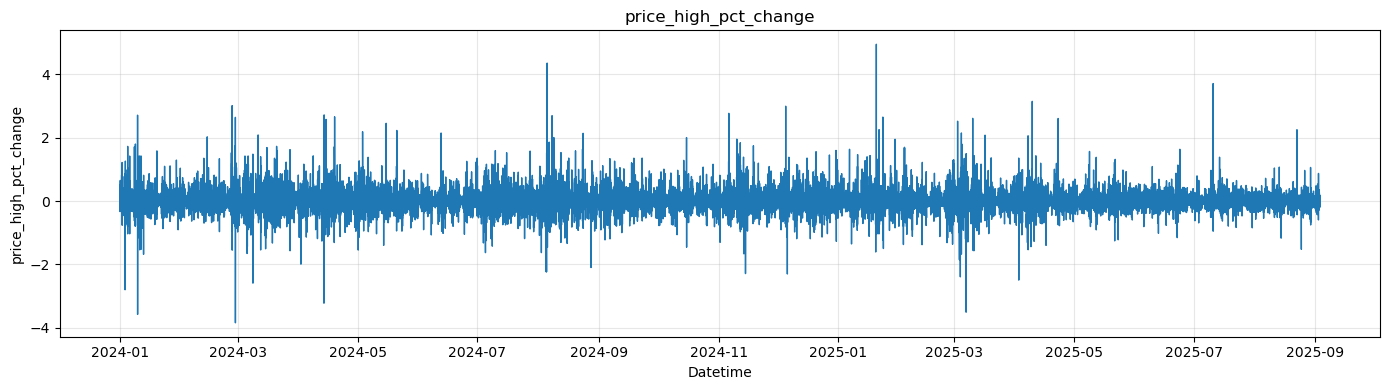

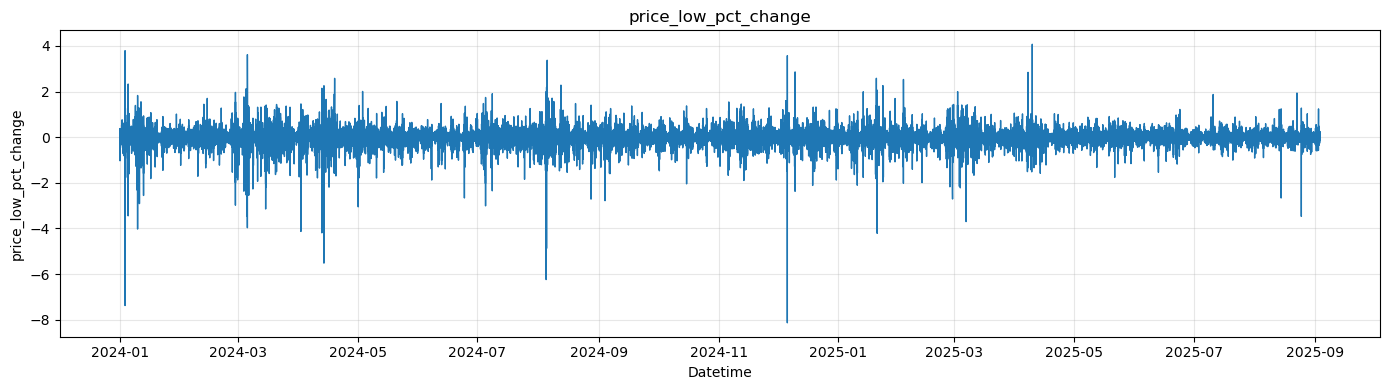

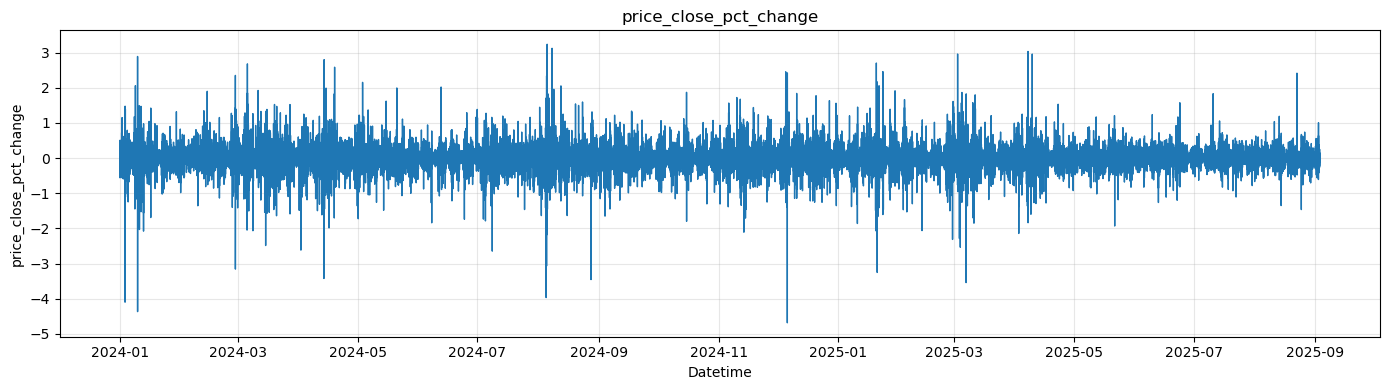

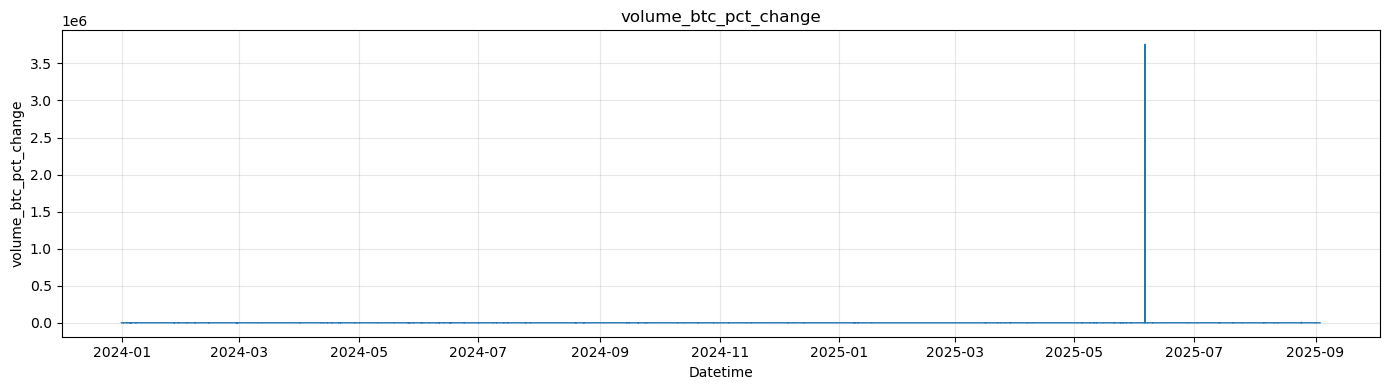

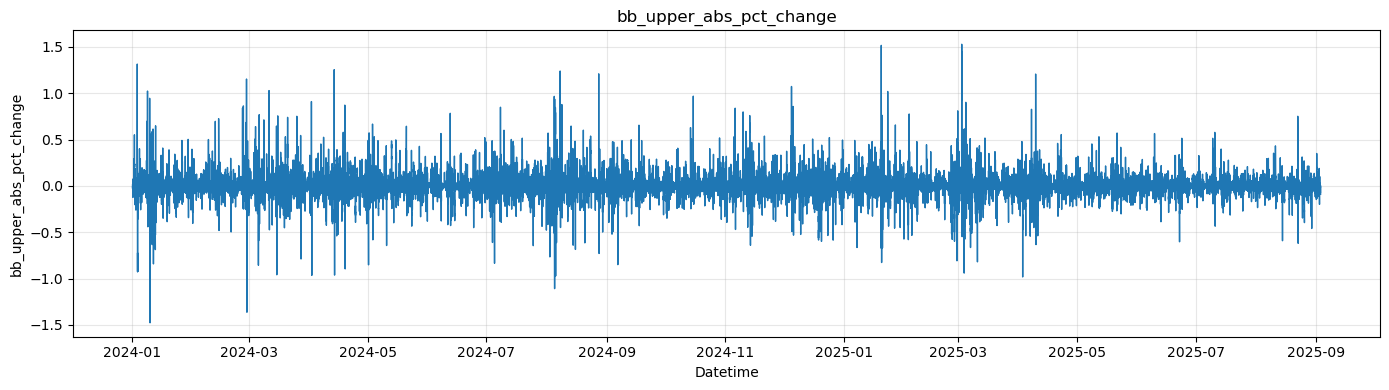

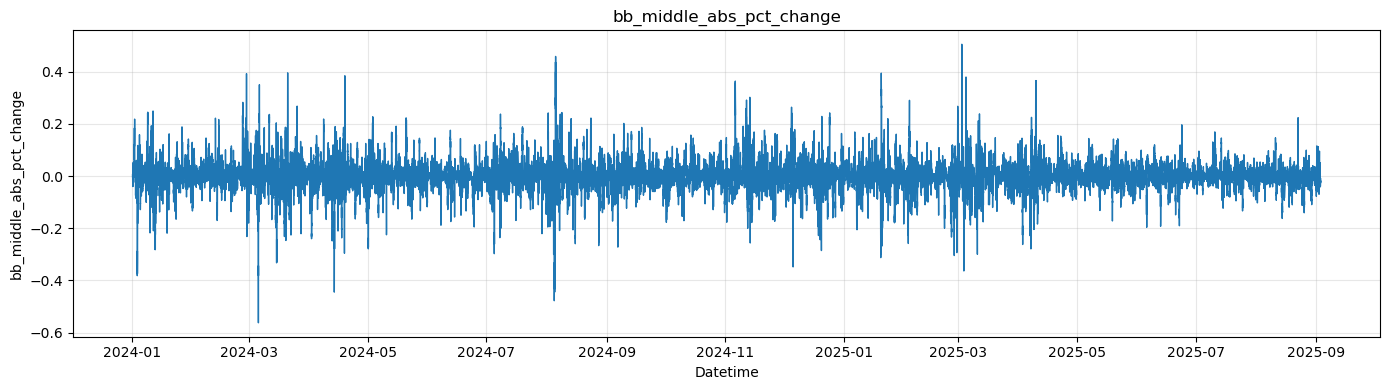

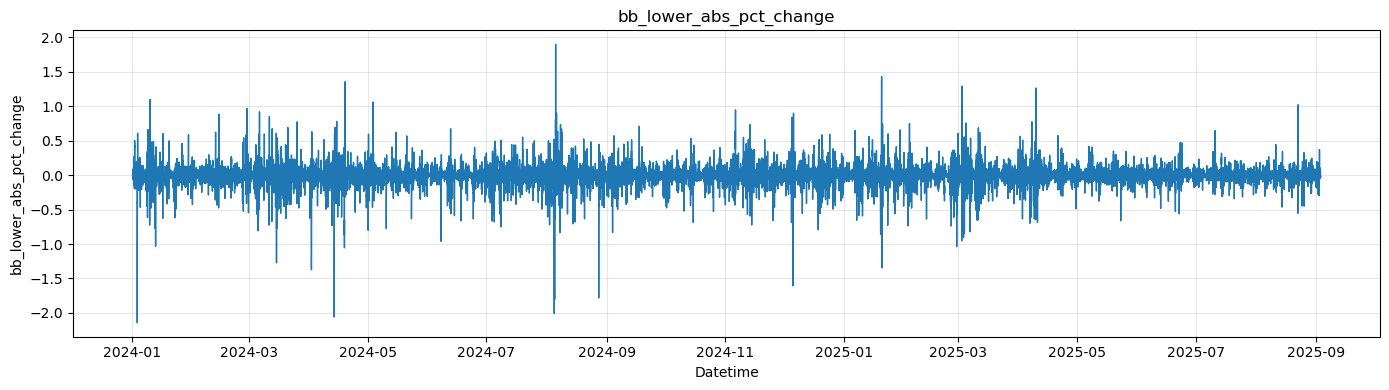

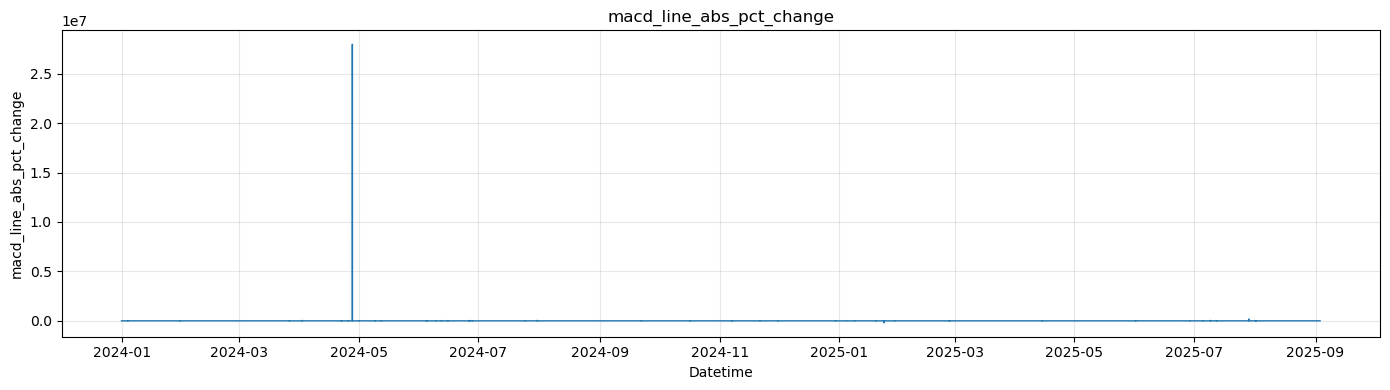

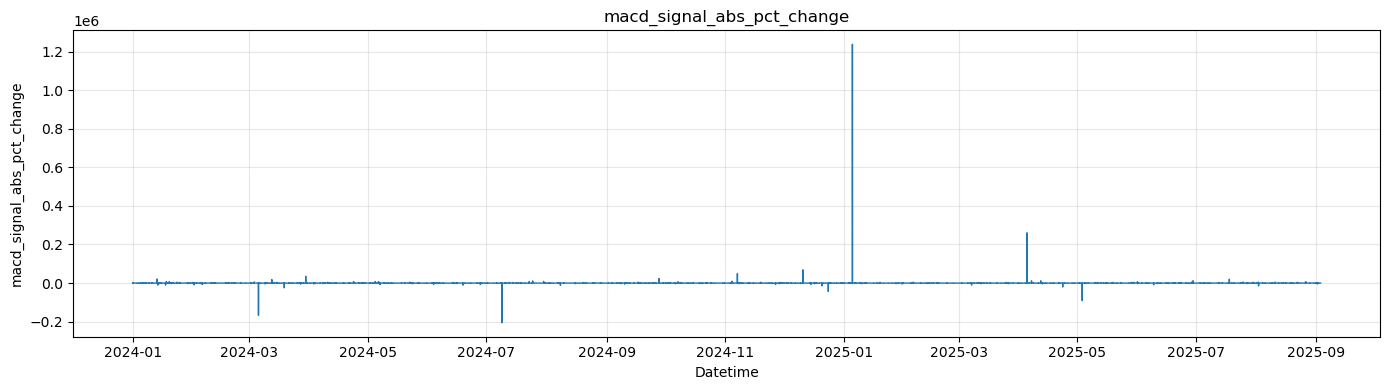

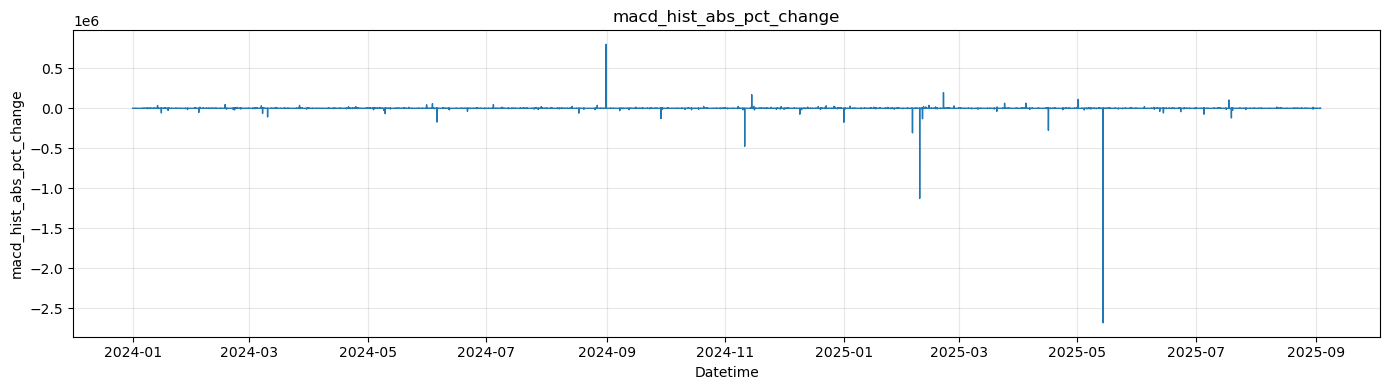

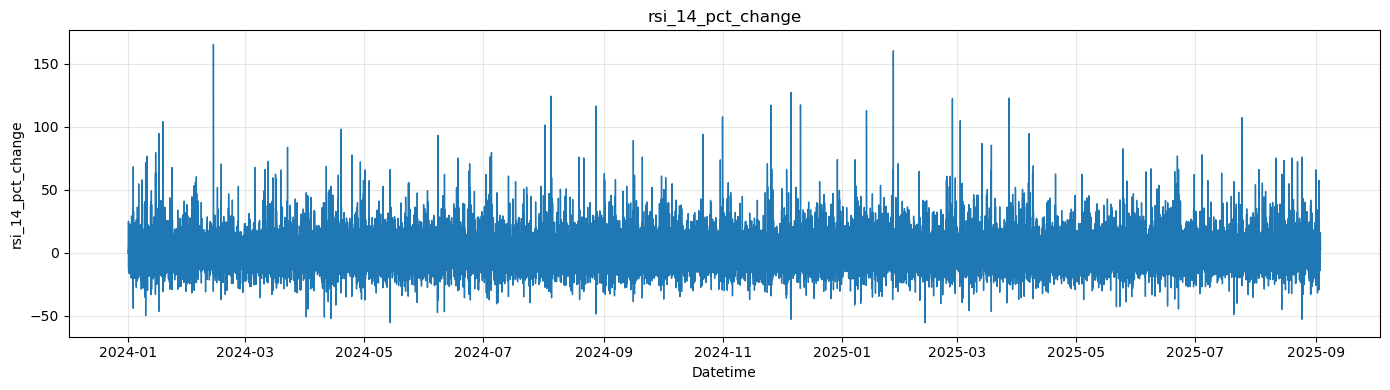

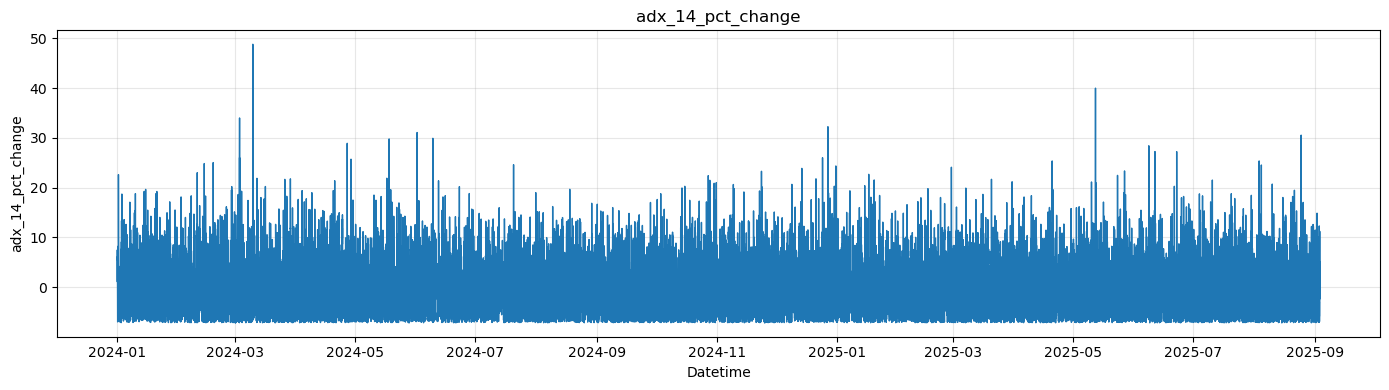

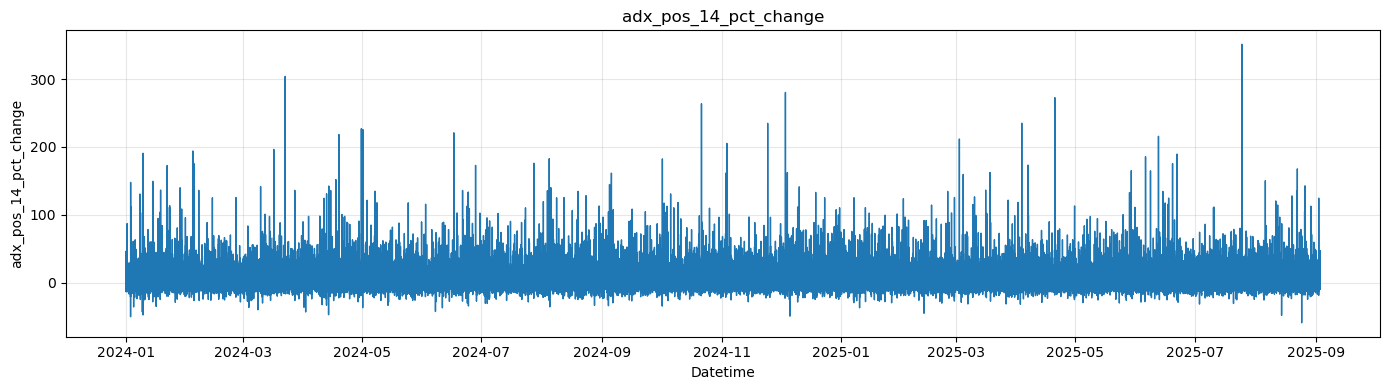

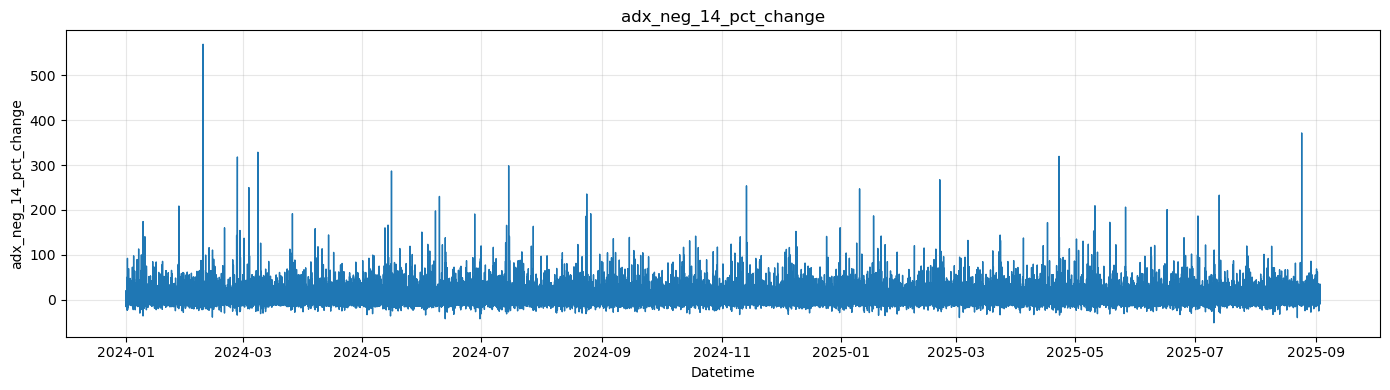

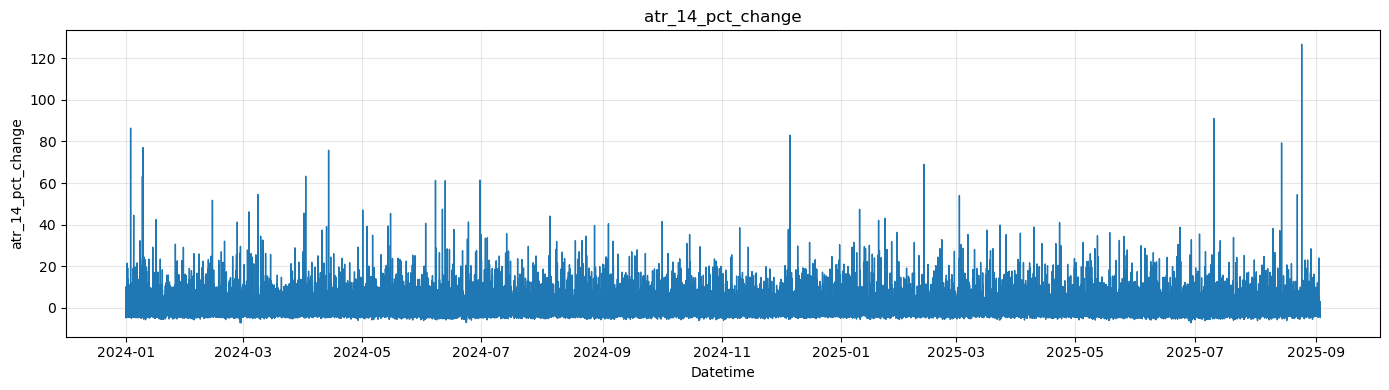

In [15]:
nans_info_cl1 = df_clean1.isna().sum()
few_nans_cl1 = nans_info_cl1[(nans_info_cl1 > 0) & (nans_info_cl1 <= 100)]

for col in few_nans_cl1.index:
    plt.figure(figsize=(14,4))
    plt.plot(df_clean1.index, df_clean1[col], linewidth=1)
    plt.title(col)
    plt.xlabel("Datetime")
    plt.ylabel(col)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

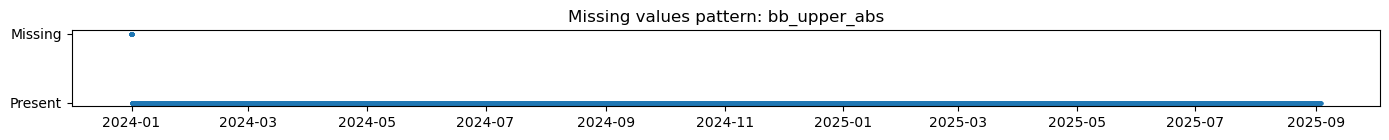

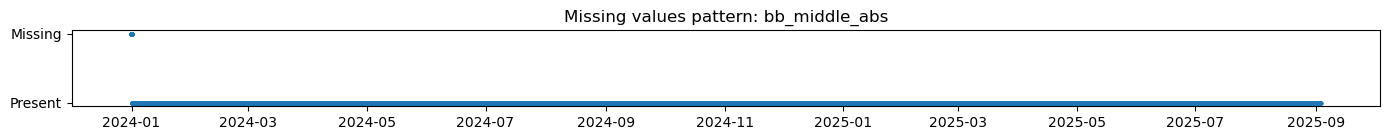

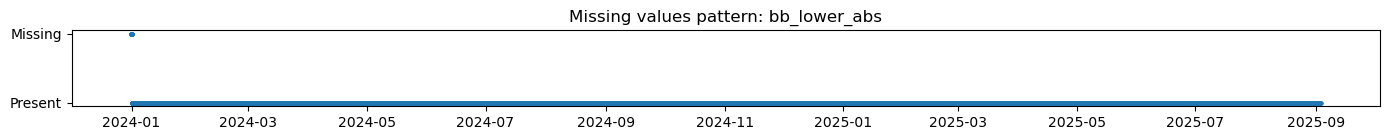

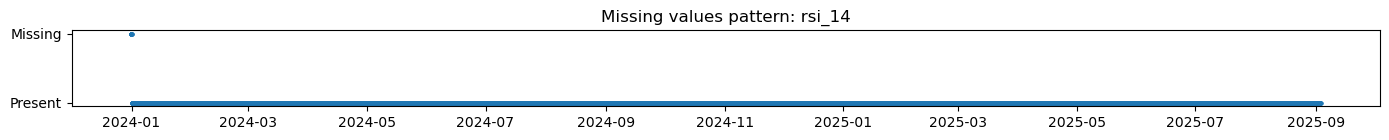

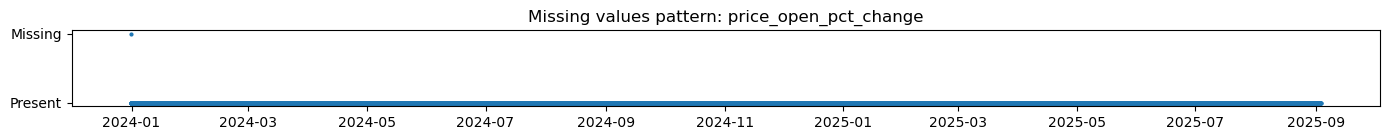

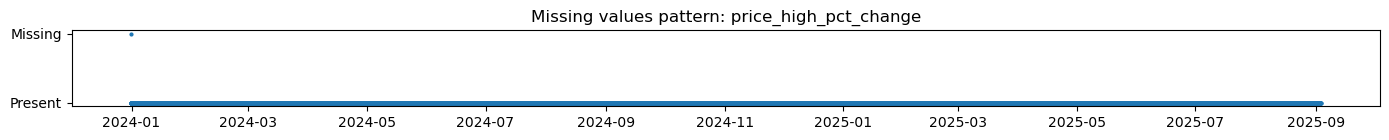

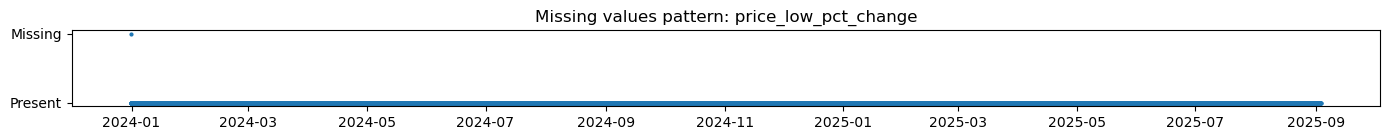

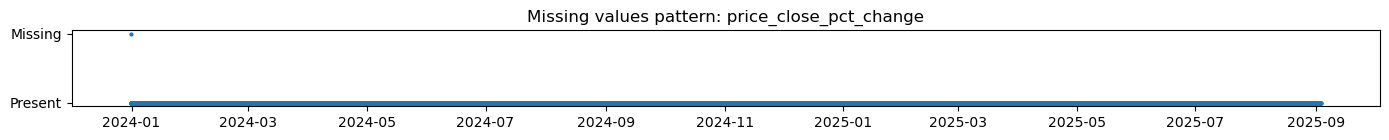

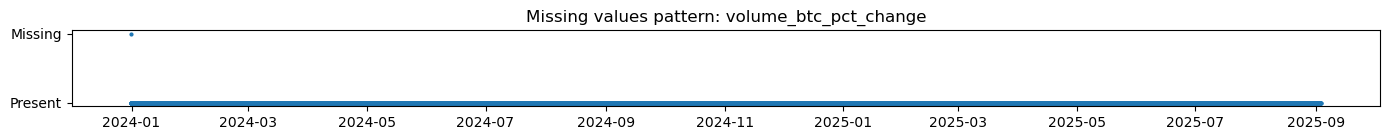

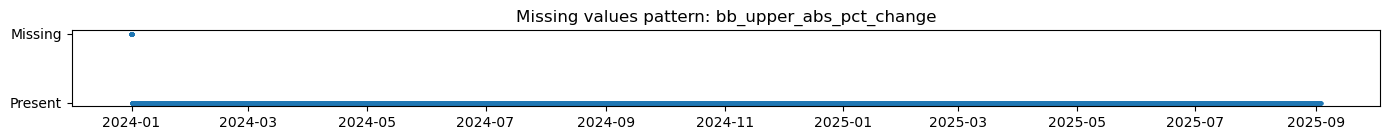

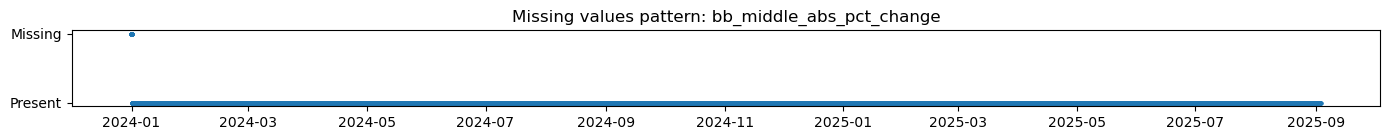

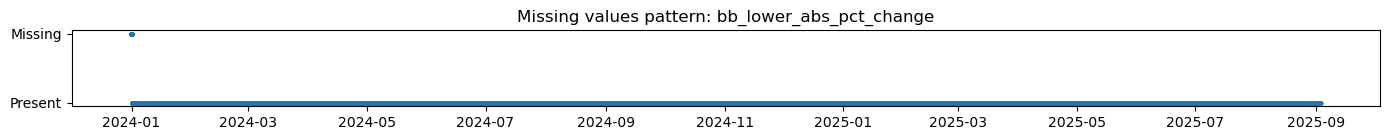

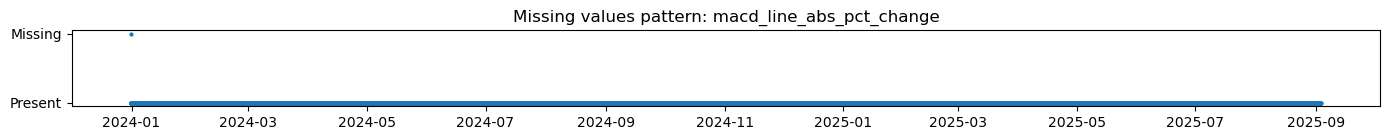

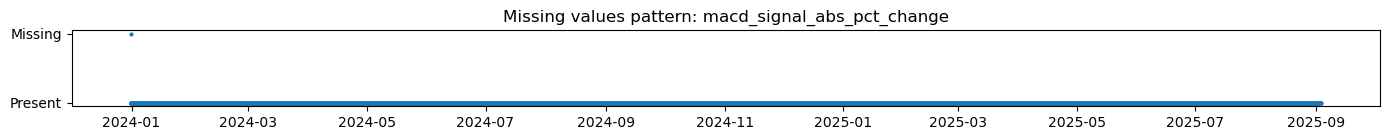

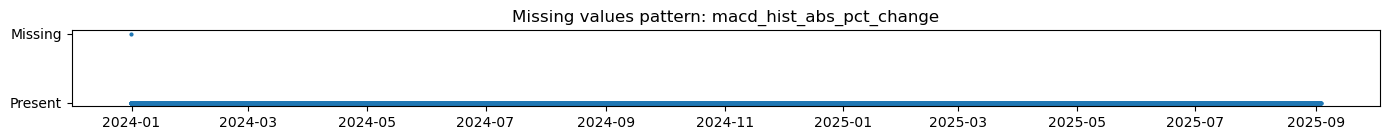

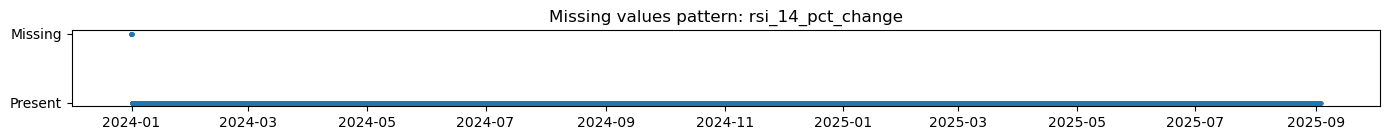

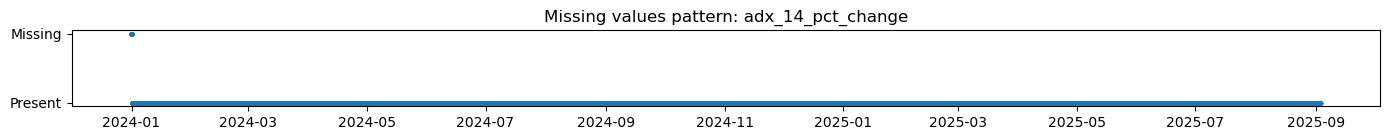

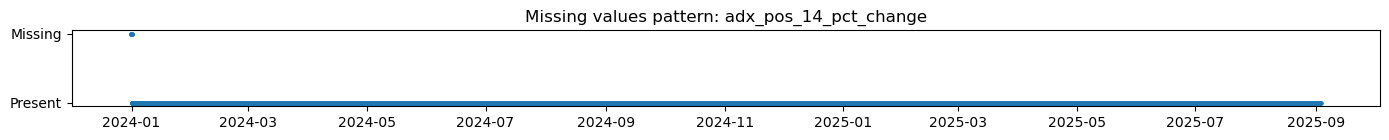

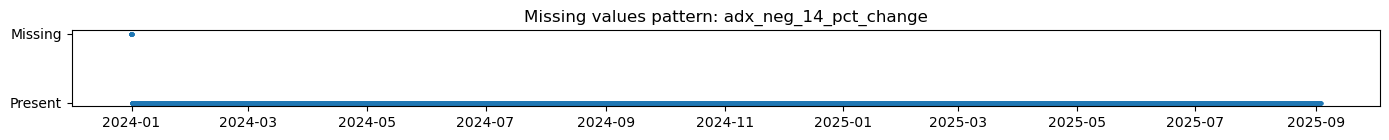

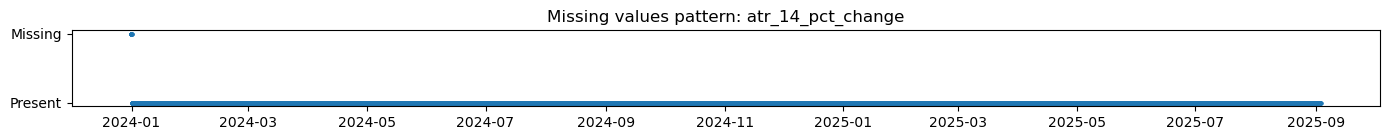

In [16]:
for col in few_nans_cl1.index:
    plt.figure(figsize=(14,1.5))

    plt.scatter(df_clean1.index, df_clean1[col].isna(), s=4)

    plt.title(f"Missing values pattern: {col}")

    plt.yticks([0,1],["Present","Missing"])

    plt.tight_layout()
    plt.show() 

In [17]:
df_clean1[nans_info_cl1[nans_info_cl1 > 1].index].head(29)

,bb_upper_abs,bb_middle_abs,bb_lower_abs,rsi_14,bb_upper_abs_pct_change,bb_middle_abs_pct_change,bb_lower_abs_pct_change,rsi_14_pct_change,adx_14_pct_change,adx_pos_14_pct_change,adx_neg_14_pct_change,atr_14_pct_change
datetime,,,,,,,,,,,,
2023-12-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 22:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


So the NaNs in the other columns are caused by the warm-up period of the indexes and calculated variables. Thus, the warm-up period is removed.   

In [18]:
first_complete_row = df_clean1.dropna().index[0]
df_clean2 = df_clean1.loc[first_complete_row:].copy()

df_clean2.replace([np.inf, -np.inf], np.nan, inplace=True)
nans_info_cl2 = df_clean2.isna().sum()
nans_info_cl2[nans_info_cl2 > 0] 

volume_btc_pct_change    2
adx_14_pct_change        1
dtype: int64

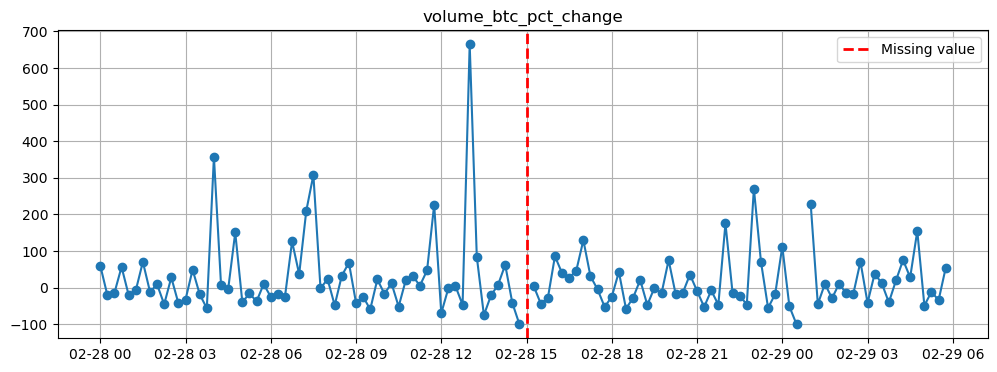

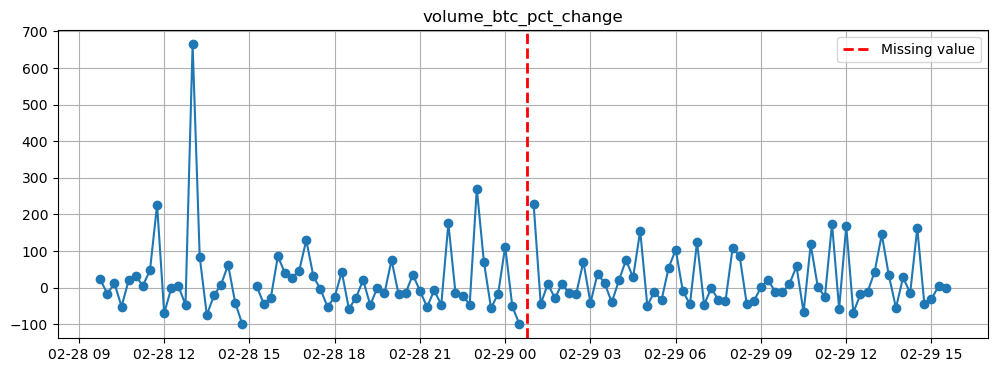

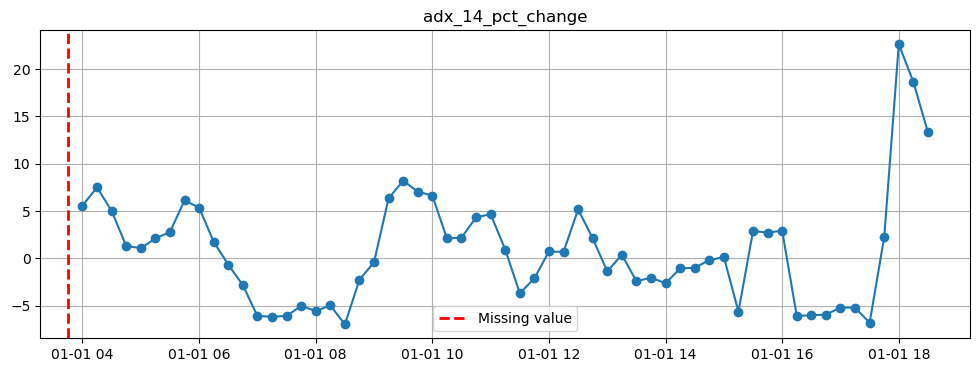

In [19]:
window = 60

for col in nans_info_cl2[nans_info_cl2 > 0].index:

    nan_idx = df_clean2[df_clean2[col].isna()].index

    for idx in nan_idx:

        loc = df_clean2.index.get_loc(idx)

        start = max(0, loc-window)
        end = min(len(df_clean2), loc+window)

        plt.figure(figsize=(12,4))

        plt.plot(
            df_clean2.iloc[start:end].index,
            df_clean2.iloc[start:end][col],
            marker='o'
        )

        plt.axvline(
            x=idx,
            color='red',
            linestyle='--',
            linewidth=2,
            label='Missing value'
        )

        plt.title(col)
        plt.grid(True)
        plt.legend()

        plt.show()

The graphs show, that the last missing values are likely to be transisionary from low to high values, so linear interpolation is likely to be a valid approach for filling the last 3 nans, especially considering that the missing values are extremely low in the data. For the adx_14_pct_change a backfill might be a resonable method to replace the value. 

In [20]:
df_clean2["adx_14_pct_change"] = (df_clean2["adx_14_pct_change"].interpolate(method="linear"))
df_clean2["volume_btc_pct_change"] = (df_clean2["volume_btc_pct_change"].interpolate(method="linear"))
df_clean2["adx_14_pct_change"] = (df_clean2["adx_14_pct_change"].bfill(limit=1))
df_clean2.isna().sum().sum()

0

In [21]:
df_clean = df_clean2.copy() 
df_clean.to_csv("crypto_dataset_bybit_15min_cleaned.csv", index=True)